<a href="https://colab.research.google.com/github/Insight-Syndicate/DSPL_GCW/blob/main/Model_building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import Necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import auth
from googleapiclient.discovery import build

# Authenticate and build Google Drive API service
auth.authenticate_user()
drive_service = build('drive', 'v3')

# Public Google Drive folder and file name
folder_id = "1XkRUF4MCrgqzis3v2C7Bx9GQaK5XgFZI"
file_name = "clean_test.csv"

# Search for the file
results = drive_service.files().list(q=f"'{folder_id}' in parents and name='{file_name}'",
                                     fields="files(id)").execute()
files = results.get("files", [])

if files:
    clean_test = pd.read_csv(f"https://drive.google.com/uc?id={files[0]['id']}")
    print(clean_test)
else:
    print(f"'{file_name}' not found in the folder.")

In [ ]:
# Public Google Drive folder and file name
folder_id = "1XkRUF4MCrgqzis3v2C7Bx9GQaK5XgFZI"
file_name = "clean_train.csv"

# Search for the file
results = drive_service.files().list(q=f"'{folder_id}' in parents and name='{file_name}'",
                                     fields="files(id)").execute()
files = results.get("files", [])

if files:
    clean_train = pd.read_csv(f"https://drive.google.com/uc?id={files[0]['id']}")
    print(clean_train)
else:
    print(f"'{file_name}' not found in the folder.")

# **Logistic Regression - Baseline Model**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

In [ ]:
# Define X and y variables
X = clean_train[['luxury_sales', 'fresh_sales', 'dry_sales', 'outlet_city_encoded']]
y = clean_train['cluster_catgeory']

In [ ]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, solver='saga', random_state=42)
log_reg_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=1000, random_state=42, solver='saga')

In [ ]:
# Predict using test data
y_pred = log_reg_model.predict(X_test)

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"R2: {r2_score(y_test, y_pred):.4f}")

Accuracy: 0.9636
MSE: 0.1702
R2: 0.9513


[[37933     1     0   103     0     1]
 [    3 30715     4     2     1   126]
 [    1     0  7462     3  2274     1]
 [  143     0     2 34256     2     1]
 [    0     0  2872     3  4883     1]
 [    0    89     3     3     2 33939]]


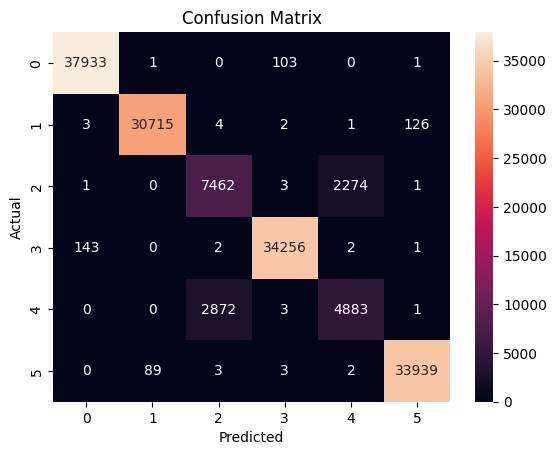

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     38038
           2       1.00      1.00      1.00     30851
           3       0.72      0.77      0.74      9741
           4       1.00      1.00      1.00     34404
           5       0.68      0.63      0.65      7759
           6       1.00      1.00      1.00     34036

    accuracy                           0.96    154829
   macro avg       0.90      0.90      0.90    154829
weighted avg       0.96      0.96      0.96    154829



# **KNN - Baseline Model**


In [ ]:
#Importing relevant libraries
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
#X, Y split
x = clean_train[['luxury_sales','fresh_sales','dry_sales','outlet_city_encoded']]
y = clean_train['cluster_catgeory']

In [ ]:
# test, train split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

To optimize KNN model we need to find the n_neighbours and this is done by making use of the gridsearchCV system.

In [ ]:
from sklearn.model_selection import GridSearchCV
#Define the parameter grid for n_neighbors
param_grid = {'n_neighbors': list(range(1, 10))}

#Create and fit the GridSearchCV object
grid = GridSearchCV(KNeighborsClassifier(algorithm='auto'), param_grid, cv=10, scoring='accuracy', n_jobs=-1)
grid.fit(x_train, y_train)

#Get the best n_neighbors value
best_k = grid.best_params_['n_neighbors']
print(f"Best k value: {best_k}")

Best k value: 1


In [ ]:
# Initialize KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=7)

# Train the classifier
knn_model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [ ]:
# Predict labels for the test set
y_pred = knn_model.predict(x_test)

# Assuming you have y_test (true labels) and y_pred (predicted labels) from your KNN model
MSE = mean_squared_error(y_test, y_pred)
r2_ = r2_score(y_test, y_pred)
Acs = accuracy_score(y_test, y_pred)

print(f"MSE: {MSE}")
print(f"R2: {r2_}")
print(f"Accuracy: {Acs}")

MSE: 0.21632252355824813
R2: 0.9381623679686149
Accuracy: 0.9526380716790782


[[37877     1     0   159     0     1]
 [    1 30760     1     4     3    82]
 [    0     0  5925     0  3815     1]
 [  114     0     2 34286     1     1]
 [    0     0  2987     3  4768     1]
 [    1   148     2     3     2 33880]]


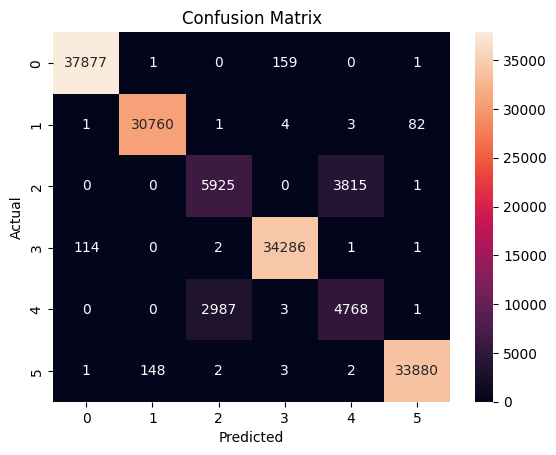

In [ ]:
#Create a confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     38038
           2       1.00      1.00      1.00     30851
           3       0.66      0.61      0.64      9741
           4       1.00      1.00      1.00     34404
           5       0.56      0.61      0.58      7759
           6       1.00      1.00      1.00     34036

    accuracy                           0.95    154829
   macro avg       0.87      0.87      0.87    154829
weighted avg       0.95      0.95      0.95    154829



Distribution of Predicted Clusters:
{np.int64(1): np.int64(37993), np.int64(2): np.int64(30909), np.int64(3): np.int64(8917), np.int64(4): np.int64(34455), np.int64(5): np.int64(8589), np.int64(6): np.int64(33966)}


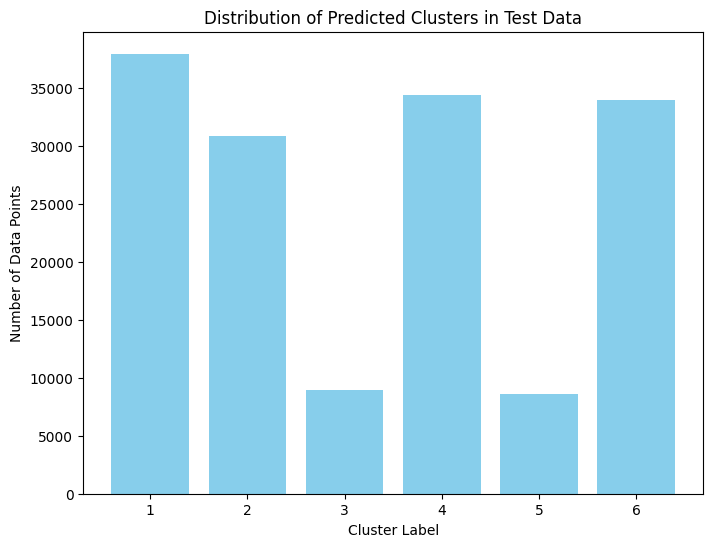

In [ ]:
# Predict cluster labels for the test data
y_predict = knn_model.predict(X_test)

# Analyze the distribution of predicted clusters
unique, counts = np.unique(y_predict, return_counts=True)
cluster_dist = dict(zip(unique, counts))

print("Distribution of Predicted Clusters:")
print(cluster_dist)

# Visualize the distribution
plt.figure(figsize=(8, 6))
plt.bar(cluster_dist.keys(), cluster_dist.values(), color='skyblue')
plt.xlabel("Cluster Label")
plt.ylabel("Number of Data Points")
plt.title("Distribution of Predicted Clusters in Test Data")
plt.show()

#**Decision Tree - Baseline Model**

In [ ]:
# Define X and y variables
x = clean_train[['luxury_sales', 'fresh_sales', 'dry_sales', 'outlet_city_encoded']]
y = clean_train['cluster_catgeory']

In [ ]:
x

,luxury_sales,fresh_sales,dry_sales,outlet_city_encoded
0,1209.60,756.00,5292.00,11
1,1590.12,1060.08,6007.12,13
2,2288.88,1481.04,9155.52,19
3,2274.94,1739.66,9099.76,19
4,2345.49,2069.55,9243.99,11
...,...,...,...,...
774140,3893.40,3893.40,3448.44,4
774141,6095.86,5557.99,6275.15,10
774142,5121.42,4820.16,4669.53,1
774143,6311.76,6311.76,5940.48,9


In [ ]:
y

,cluster_catgeory
0,4
1,1
2,4
3,4
4,4
...,...
774140,3
774141,3
774142,3
774143,3


In [ ]:
# test, train split
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.25, random_state=1, stratify=y)

In [ ]:
#Train the decison tree model
from sklearn.tree import DecisionTreeClassifier
dt_d = DecisionTreeClassifier()
dt_d.fit(X_train, Y_train)

DecisionTreeClassifier()

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"R2: {r2_score(y_test, y_pred):.4f}")

Accuracy: 0.9526
MSE: 0.2163
R2: 0.9382


[[37877     1     0   159     0     1]
 [    1 30760     1     4     3    82]
 [    0     0  5925     0  3815     1]
 [  114     0     2 34286     1     1]
 [    0     0  2987     3  4768     1]
 [    1   148     2     3     2 33880]]


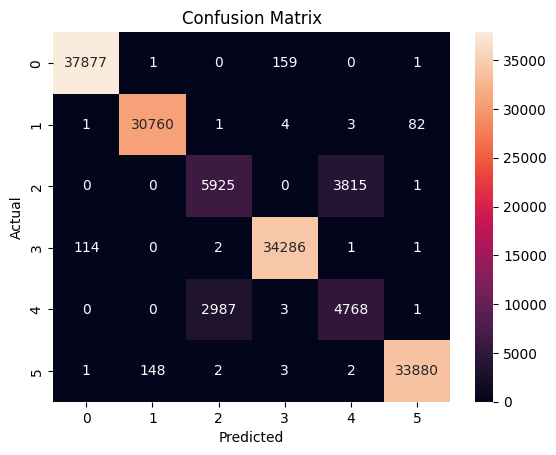

In [ ]:
#Create a confusion matrix to analyse the performance of the DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     38038
           2       1.00      1.00      1.00     30851
           3       0.66      0.61      0.64      9741
           4       1.00      1.00      1.00     34404
           5       0.56      0.61      0.58      7759
           6       1.00      1.00      1.00     34036

    accuracy                           0.95    154829
   macro avg       0.87      0.87      0.87    154829
weighted avg       0.95      0.95      0.95    154829



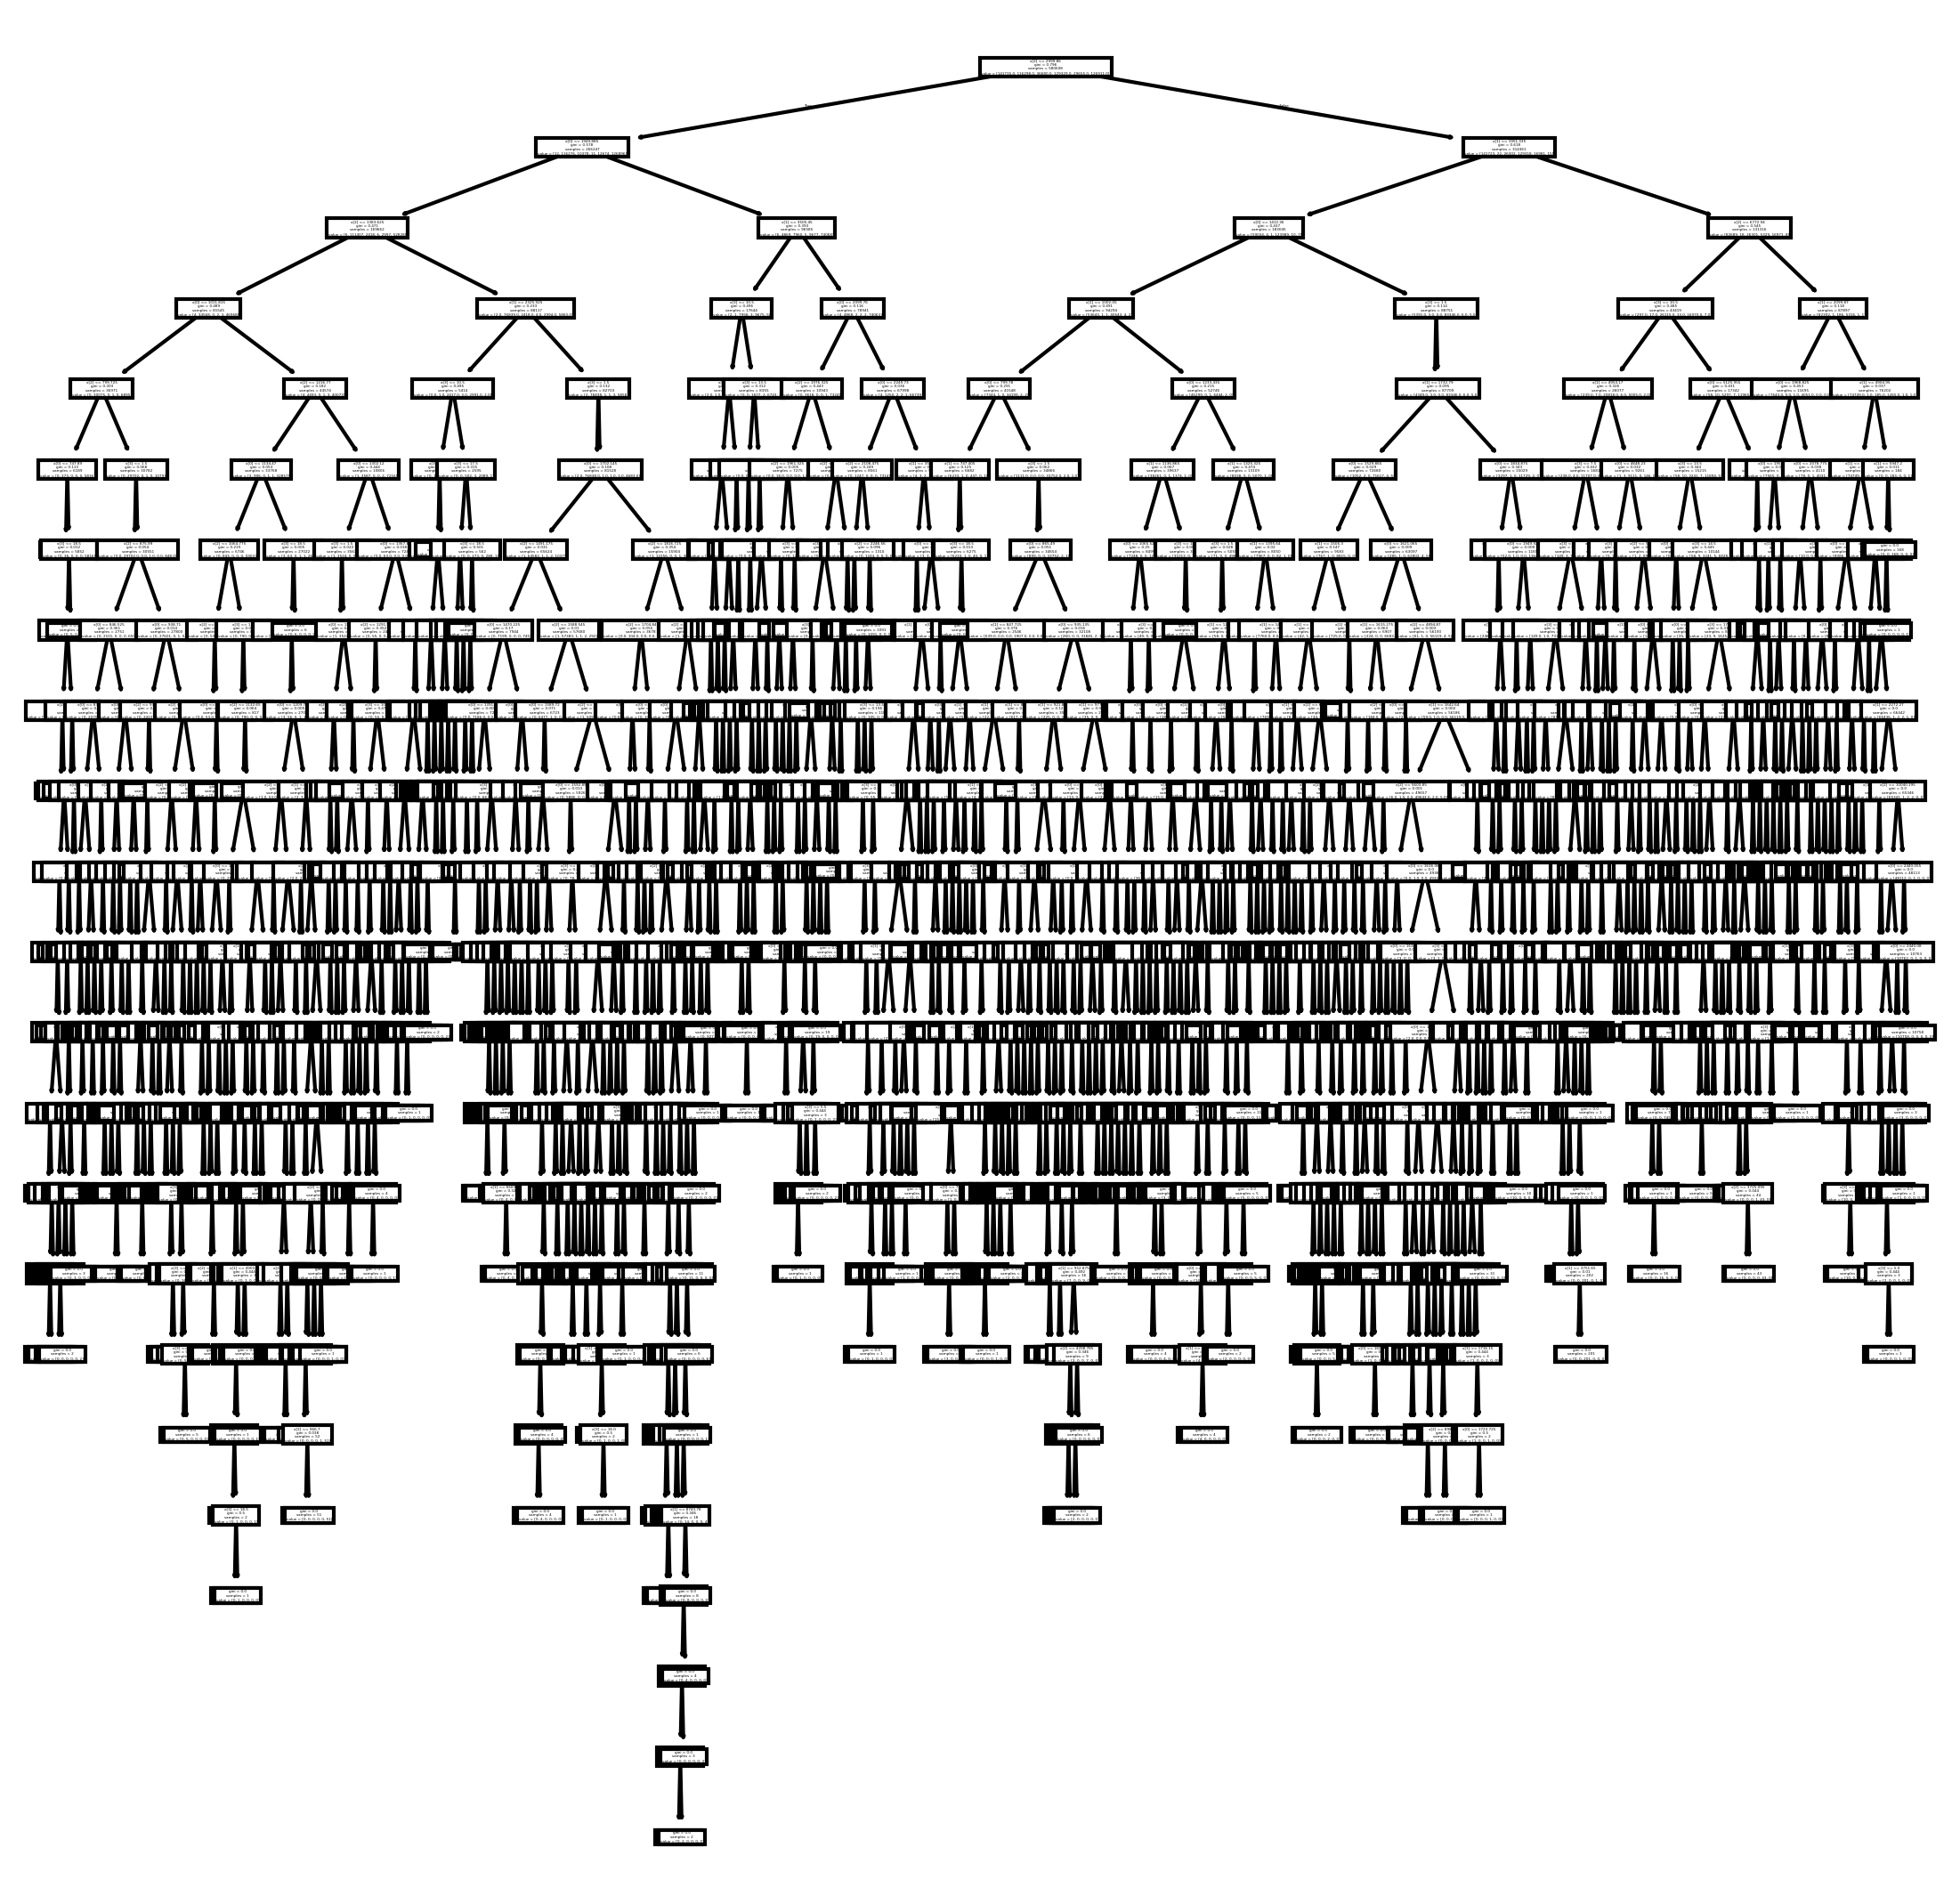

In [ ]:
from sklearn import tree
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 9), dpi=300)
tree.plot_tree(dt_d)
plt.show()

# **Random Forest - Baseline Model**

In [ ]:
# Checking for feature balance in the train data
clean_train['cluster_catgeory'].value_counts()

,count
cluster_catgeory,
1,188980
4,172439
6,169215
2,155064
3,48907
5,39540


In [ ]:
# Importing code bloxks from the scikit learn library
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score

Since customer Id has no prediction value and is only a unique identifier it is not included in the features in the x dataframe since including it migh lead to over fitting the model.

In [ ]:
# Difine X and Y variables
x = clean_train[['luxury_sales','fresh_sales','dry_sales','outlet_city_encoded']]
y = clean_train['cluster_catgeory']

In [ ]:
# test, train split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# creating the randome forest classifier (rfc) model
rfc_model = RandomForestClassifier(n_estimators=25, random_state=42)

n_estimators is the hyperparameter in random forest which tells the number of decision trees in the forest. Higher n_estimators mean higher accuracy but also higher computational cost and time. Therefore, 25 has been settled on as the balance between accuracy, computational cost as futher increase in this hyper parameter would only provide dimnishing returns.

In [ ]:
# Train the model
rfc_model.fit(x_train, y_train)

RandomForestClassifier(n_estimators=25, random_state=42)

In [ ]:
# Predict using the x_test data
y_pred = rfc_model.predict(x_test)

In [ ]:
# Evaluate the model
MSE = mean_squared_error(y_test, y_pred)
r2_= r2_score(y_test, y_pred)
Acs = accuracy_score(y_test, y_pred)

print(f"MSE:{MSE}")
print(f"R2:{r2_}")
print(f"Accuracy:{Acs}")

MSE:0.006187471339348572
R2:0.9982312587261198
Accuracy:0.9992959975198444


In [ ]:
# confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[38013,     1,     0,    23,     0,     1],
       [    1, 30834,     3,     4,     1,     8],
       [    0,     0,  9739,     0,     1,     1],
       [   19,     0,     1, 34381,     2,     1],
       [    0,     0,    13,     3,  7742,     1],
       [    0,    17,     4,     3,     1, 34011]])

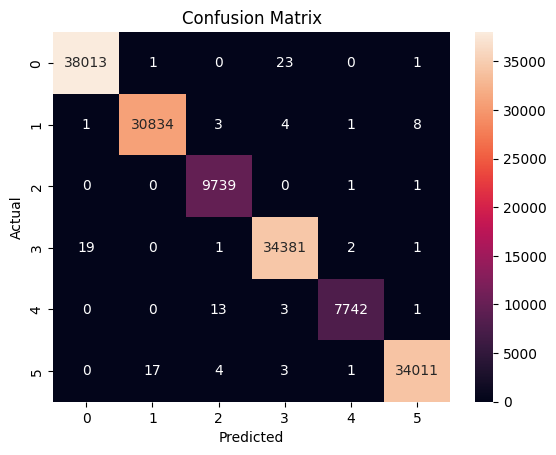

In [ ]:
# heatmap of contribution matrix
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

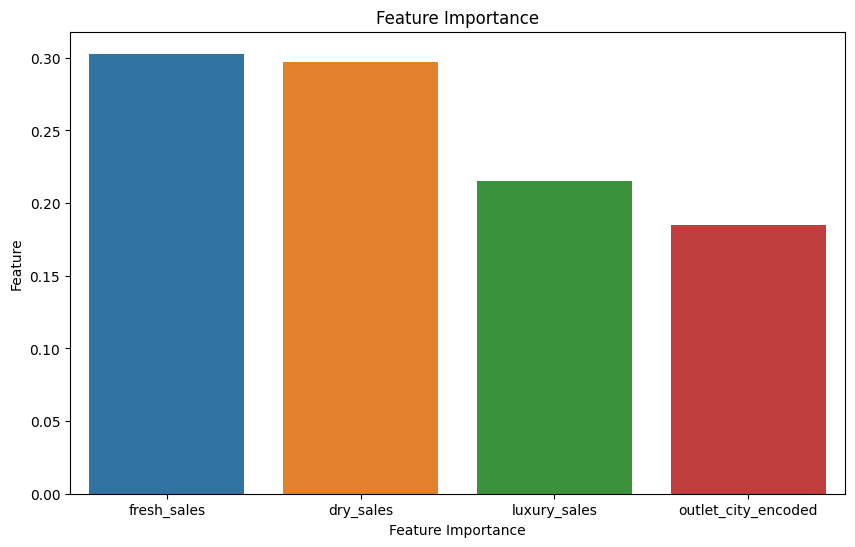

In [ ]:
# importance of each feature
feature_importance = rfc_model.feature_importances_
features = x_train.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# plot
plt.figure(figsize=(10, 6))
sns.barplot(y='Importance', x='Feature', data=importance_df, hue='Feature')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

In [ ]:
# classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     38038
           2       1.00      1.00      1.00     30851
           3       1.00      1.00      1.00      9741
           4       1.00      1.00      1.00     34404
           5       1.00      1.00      1.00      7759
           6       1.00      1.00      1.00     34036

    accuracy                           1.00    154829
   macro avg       1.00      1.00      1.00    154829
weighted avg       1.00      1.00      1.00    154829



# **Gradient Boosting - Baseline Model**

In [ ]:
# Checking for feature balance in the train data
clean_train['cluster_catgeory'].value_counts()

,count
cluster_catgeory,
1,188980
4,172439
6,169215
2,155064
3,48907
5,39540


In [ ]:
# Importing code bloxks from the scikit learn library
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
# Difine X and Y variables
x = clean_train[['luxury_sales','fresh_sales','dry_sales','outlet_city_encoded']]
y = clean_train['cluster_catgeory']

In [ ]:
# test, train split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# create the Gradient Boosting Classificatio (gbc) model
gbc_model = GradientBoostingClassifier(n_estimators=25, random_state=42)

In [ ]:
# Train the model
gbc_model.fit(x_train, y_train)

GradientBoostingClassifier(n_estimators=25, random_state=42)

In [ ]:
# predict using the model
y_pred = gbc_model.predict(x_test)

In [ ]:
# Evaluate the model
MSE = mean_squared_error(y_test, y_pred)
r2_= r2_score(y_test, y_pred)
Acs = accuracy_score(y_test, y_pred)

print(f"MSE:{MSE}")
print(f"R2:{r2_}")
print(f"Accuracy:{Acs}")

MSE:0.13923102261204295
R2:0.9601996287671881
Accuracy:0.9766129084344665


[[37748     1     0   288     0     1]
 [    5 30729     3     2     2   110]
 [    1     0  8382     5  1352     1]
 [  212     0     2 34188     1     1]
 [    2     0  1350     3  6403     1]
 [    0   271     2     3     2 33758]]


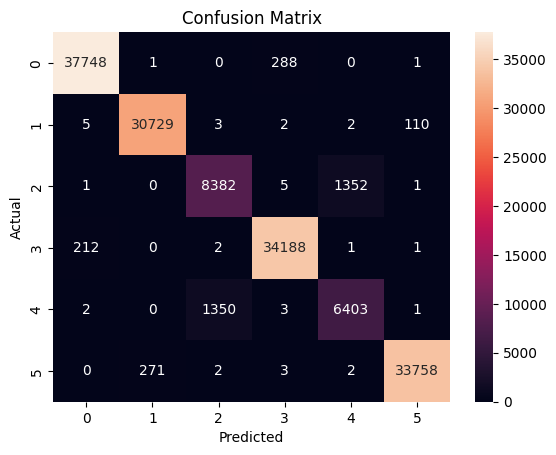

In [ ]:
# confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

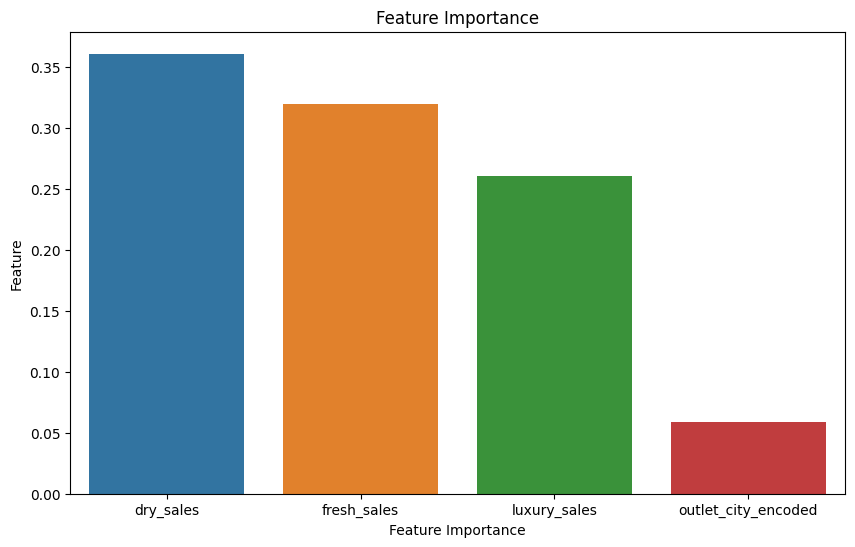

In [ ]:
# importance of each feature
feature_importance = gbc_model.feature_importances_
features = x_train.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# plot
plt.figure(figsize=(10, 6))
sns.barplot(y='Importance', x='Feature', data=importance_df, hue='Feature')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

In [ ]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.99      0.99      0.99     38038
           2       0.99      1.00      0.99     30851
           3       0.86      0.86      0.86      9741
           4       0.99      0.99      0.99     34404
           5       0.83      0.83      0.83      7759
           6       1.00      0.99      0.99     34036

    accuracy                           0.98    154829
   macro avg       0.94      0.94      0.94    154829
weighted avg       0.98      0.98      0.98    154829



# **Data Scaling**

## **Test**

We are using the robust scaller since our data is skewed and luxury sales has outliers. Since this technique scales using the median and IQR it is best suited to deal with the skewness and the extreme values.

In [ ]:
from sklearn.preprocessing import RobustScaler
# Identify numerical columns
numerical_columns = ['luxury_sales', 'fresh_sales', 'dry_sales']

# Initialize RobustScaler
DSPL_scaler = RobustScaler()

# Fit on training numerical data and transform both train & test
clean_test[numerical_columns] = DSPL_scaler.fit_transform(clean_test[numerical_columns])
clean_test

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,outlet_city_encoded
0,33574,Batticaloa,0.857034,0.041937,1.631090,1
1,10089,Batticaloa,-0.003695,-0.156121,1.057081,1
2,38329,Batticaloa,-0.770778,-0.418864,0.268678,1
3,11376,Batticaloa,-0.074264,-0.206474,1.026639,1
4,12410,Batticaloa,-0.606394,-0.364423,0.312022,1
...,...,...,...,...,...,...
40744,33698,Wattala,1.949650,0.156019,0.029930,21
40745,4185,Wattala,1.306009,-0.071865,-0.122086,21
40746,28664,Wattala,1.880468,0.114708,-0.010279,21
40747,11874,Wattala,2.302562,0.160308,0.103720,21


## **Train**

We are using the robust scaller since our data is skewed and luxury sales has outliers. Since this technique scales using the median and IQR it is best suited to deal with the skewness and the extreme values.

In [ ]:
from sklearn.preprocessing import RobustScaler
# Identify numerical columns
numerical_columns = ['luxury_sales', 'fresh_sales', 'dry_sales']

# Initialize RobustScaler
DSPL_scaler = RobustScaler()

# Fit on training numerical data and transform both train & test
clean_train[numerical_columns] = DSPL_scaler.fit_transform(clean_train[numerical_columns])
clean_train

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory,outlet_city_encoded
0,10493832.0,Kelaniya,-0.449457,-0.514864,0.291089,4,11
1,10178643.0,Moratuwa,-0.111244,-0.454663,0.424165,1,13
2,10513916.0,Wattala,0.509826,-0.371322,1.010049,4,19
3,10334589.0,Wattala,0.497436,-0.320120,0.999672,4,19
4,10458365.0,Kelaniya,0.560142,-0.254809,1.026512,4,11
...,...,...,...,...,...,...,...
774140,10197979.0,Gampaha,1.935952,0.106275,-0.051979,3,4
774141,10494575.0,Katunayake,3.893537,0.435829,0.474042,3,10
774142,10565682.0,Colombo,3.027438,0.289754,0.175253,3,1
774143,10351977.0,Kandy,4.085433,0.585060,0.411764,3,9


# **Logistic Regression**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

In [ ]:
# Define X and y variables
X = clean_train[['luxury_sales', 'fresh_sales', 'dry_sales', 'outlet_city_encoded']]
y = clean_train['cluster_catgeory']

In [ ]:
# Split data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, solver='saga', random_state=42)
log_reg_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='saga')

In [ ]:
# Predict using test data
y_pred = log_reg_model.predict(X_test)

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"R2: {r2_score(y_test, y_pred):.4f}")

Accuracy: 0.9628
MSE: 0.1801
R2: 0.9484


[[37718     2     0   155     0     1]
 [    2 30780     0     2     4   134]
 [    1     0  7443     0  2303     1]
 [  153     0     2 34212     3     0]
 [    1     0  2841     1  5118     1]
 [    0   140     3     3     3 33802]]


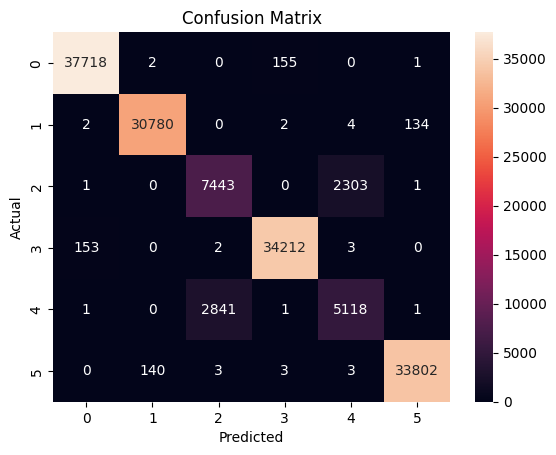

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     37876
           2       1.00      1.00      1.00     30922
           3       0.72      0.76      0.74      9748
           4       1.00      1.00      1.00     34370
           5       0.69      0.64      0.66      7962
           6       1.00      1.00      1.00     33951

    accuracy                           0.96    154829
   macro avg       0.90      0.90      0.90    154829
weighted avg       0.96      0.96      0.96    154829



## **Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, mean_squared_error

# Predict on training, validation, and test sets
y_train_pred = log_reg_model.predict(X_train)
y_val_pred = log_reg_model.predict(X_val)
y_test_pred = log_reg_model.predict(X_test)

# Calculate accuracy and MSE for training, validation, and test sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Print the results
print(f"Training Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")
print(f"Training MSE: {train_mse:.4f}, Validation MSE: {val_mse:.4f}, Test MSE: {test_mse:.4f}")

# Determine if the model is overfitting or underfitting
if train_accuracy > val_accuracy and val_accuracy > test_accuracy:
    print("The model is overfitting.")
elif train_accuracy < val_accuracy:
    print("The model is underfitting.")
else:
    print("The model is well-fitted.")

Training Accuracy: 0.9629, Validation Accuracy: 0.9623, Test Accuracy: 0.9628
Training MSE: 0.1802, Validation MSE: 0.1836, Test MSE: 0.1801
The model is well-fitted.


#**KNN Model**

In [ ]:
#Importing relevant libraries
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
#X, Y split
X = clean_train[['luxury_sales','fresh_sales','dry_sales','outlet_city_encoded']]
y = clean_train['cluster_catgeory']

In [ ]:
# Split data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

To optimize KNN model we need to find the n_neighbours and this is done by making use of the gridsearchCV system.

In [ ]:
from sklearn.model_selection import GridSearchCV
#Define the parameter grid for n_neighbors
param_grid = {'n_neighbors': list(range(1, 10))}

#Create and fit the GridSearchCV object
grid = GridSearchCV(KNeighborsClassifier(algorithm='auto'), param_grid, cv=10, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

#Get the best n_neighbors value
best_k = grid.best_params_['n_neighbors']
print(f"Best k value: {best_k}")

Best k value: 5


In [ ]:
# Initialize KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the classifier using the scaled training data (X_train, y_train)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
# Predict labels for the test set
y_pred = knn_model.predict(X_test)


MSE = mean_squared_error(y_test, y_pred)
r2_ = r2_score(y_test, y_pred)
Acs = accuracy_score(y_test, y_pred)

print(f"MSE: {MSE}")
print(f"R2: {r2_}")
print(f"Accuracy: {Acs}")

MSE: 0.0012207015481595824
R2: 0.9996505485490482
Accuracy: 0.9997739441577482


[[37871     2     1     1     0     1]
 [    2 30915     0     2     2     1]
 [    0     0  9744     0     2     2]
 [    0     0     1 34365     4     0]
 [    0     1     1     1  7958     1]
 [    0     0     5     3     2 33941]]


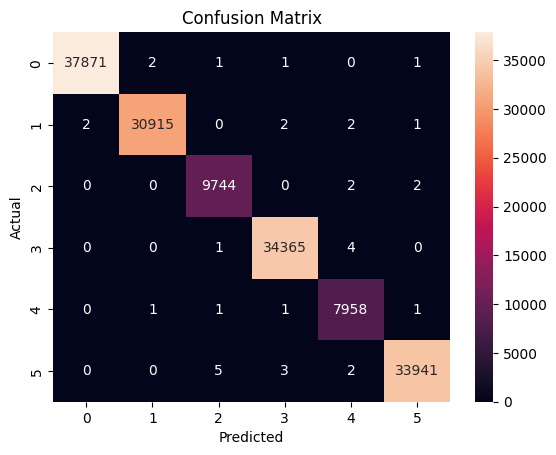

In [ ]:
#Create a confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     37876
           2       1.00      1.00      1.00     30922
           3       1.00      1.00      1.00      9748
           4       1.00      1.00      1.00     34370
           5       1.00      1.00      1.00      7962
           6       1.00      1.00      1.00     33951

    accuracy                           1.00    154829
   macro avg       1.00      1.00      1.00    154829
weighted avg       1.00      1.00      1.00    154829



Distribution of Predicted Clusters:
{np.int64(1): np.int64(37873), np.int64(2): np.int64(30918), np.int64(3): np.int64(9752), np.int64(4): np.int64(34372), np.int64(5): np.int64(7968), np.int64(6): np.int64(33946)}


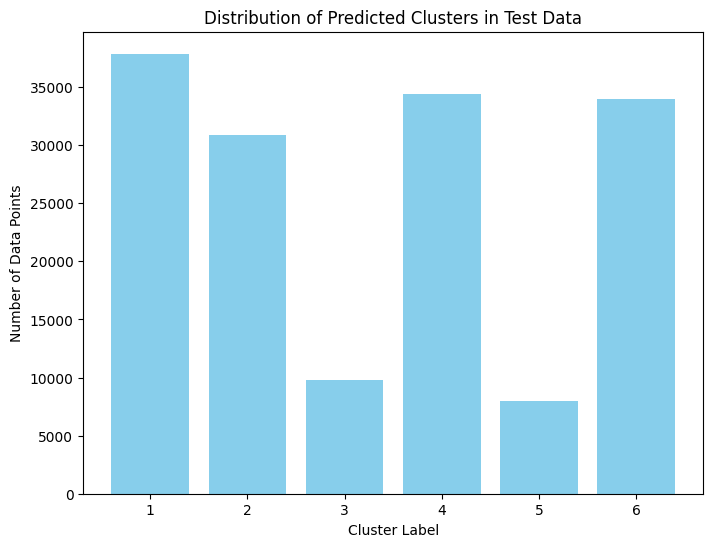

In [ ]:
# Analyze the distribution of predicted clusters
unique, counts = np.unique(y_pred, return_counts=True)
cluster_dist = dict(zip(unique, counts))

print("Distribution of Predicted Clusters:")
print(cluster_dist)

# Visualize the distribution
plt.figure(figsize=(8, 6))
plt.bar(cluster_dist.keys(), cluster_dist.values(), color='skyblue')
plt.xlabel("Cluster Label")
plt.ylabel("Number of Data Points")
plt.title("Distribution of Predicted Clusters in Test Data")
plt.show()

## **Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, mean_squared_error

# Predict on training, validation, and test sets
y_train_pred = knn_model.predict(X_train)
y_val_pred = knn_model.predict(X_val)
y_test_pred = knn_model.predict(X_test)

# Calculate accuracy and MSE for training, validation, and test sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Print the results
print(f"Training Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")
print(f"Training MSE: {train_mse:.4f}, Validation MSE: {val_mse:.4f}, Test MSE: {test_mse:.4f}")

# Detect overfitting or underfitting
if train_accuracy > val_accuracy + 0.005:
    print("The model is overfitting.")
elif train_accuracy < 0.90 and val_accuracy < 0.90:
    print("The model is underfitting.")
else:
    print("The model is well-fitted.")

Training Accuracy: 0.9997, Validation Accuracy: 0.9998, Test Accuracy: 0.9998
Training MSE: 0.0017, Validation MSE: 0.0010, Test MSE: 0.0012
The model is well-fitted.


In [ ]:
# Checking how well the model distinguish between classes
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarizing the labels (since it's multi-class)
y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4, 5, 6])

y_pred_probs = knn_model.predict_proba(X_test)

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test_bin, y_pred_probs, average='macro', multi_class='ovr')
print(f"ROC-AUC: {roc_auc}")

ROC-AUC: 0.9998529257218097


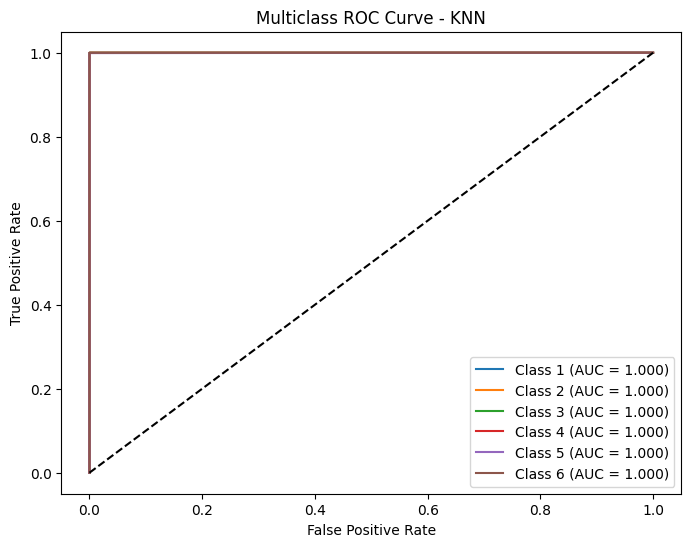

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Convert y_test to a binarized format (One-vs-Rest)
y_val_binarized = label_binarize(y_val, classes=knn_model.classes_)

# Get probability scores for all classes using X_val
y_probs = knn_model.predict_proba(X_val)

# Plot ROC Curve for each class
plt.figure(figsize=(8, 6))

for i in range(y_val_binarized.shape[1]):  # Loop through each class
    fpr, tpr, _ = roc_curve(y_val_binarized[:, i], y_probs[:, i])
    auc_score = roc_auc_score(y_val_binarized[:, i], y_probs[:, i])
    plt.plot(fpr, tpr, label=f'Class {knn_model.classes_[i]} (AUC = {auc_score:.3f})')

# Plot settings
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve - KNN')
plt.legend()
plt.show()

# **Decsion Tree Model**

In [ ]:
# Define X and y variables
x = clean_train[['luxury_sales', 'fresh_sales', 'dry_sales', 'outlet_city_encoded']]
y = clean_train['cluster_catgeory']

In [ ]:
X

,luxury_sales,fresh_sales,dry_sales,outlet_city_encoded
0,-0.449457,-0.514864,0.291089,11
1,-0.111244,-0.454663,0.424165,13
2,0.509826,-0.371322,1.010049,19
3,0.497436,-0.320120,0.999672,19
4,0.560142,-0.254809,1.026512,11
...,...,...,...,...
774140,1.935952,0.106275,-0.051979,4
774141,3.893537,0.435829,0.474042,10
774142,3.027438,0.289754,0.175253,1
774143,4.085433,0.585060,0.411764,9


In [ ]:
y

,cluster_catgeory
0,4
1,1
2,4
3,4
4,4
...,...
774140,3
774141,3
774142,3
774143,3


In [ ]:
# test, train split
from sklearn.model_selection import train_test_split
# Split data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
#Train the decison tree model
from sklearn.tree import DecisionTreeClassifier
dt_d = DecisionTreeClassifier()
dt_d.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
# Verify dimensions
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (464487, 4)
y_train shape: (464487,)


In [ ]:
# Evaluate the model
y_pred = dt_d.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"R2: {r2_score(y_test, y_pred):.4f}")

Accuracy: 0.9982
MSE: 0.0187
R2: 0.9946


[[37828     2     2    42     1     1]
 [    2 30856     1     5     3    55]
 [    4     1  9723     2    16     2]
 [   46     1     1 34319     3     0]
 [    0     1    18     2  7939     2]
 [    2    52     4     3     5 33885]]


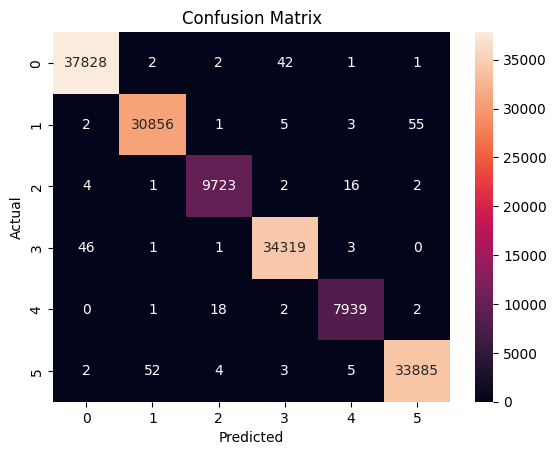

In [ ]:
#Create a confusion matrix to analyse the performance of the DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     37876
           2       1.00      1.00      1.00     30922
           3       1.00      1.00      1.00      9748
           4       1.00      1.00      1.00     34370
           5       1.00      1.00      1.00      7962
           6       1.00      1.00      1.00     33951

    accuracy                           1.00    154829
   macro avg       1.00      1.00      1.00    154829
weighted avg       1.00      1.00      1.00    154829



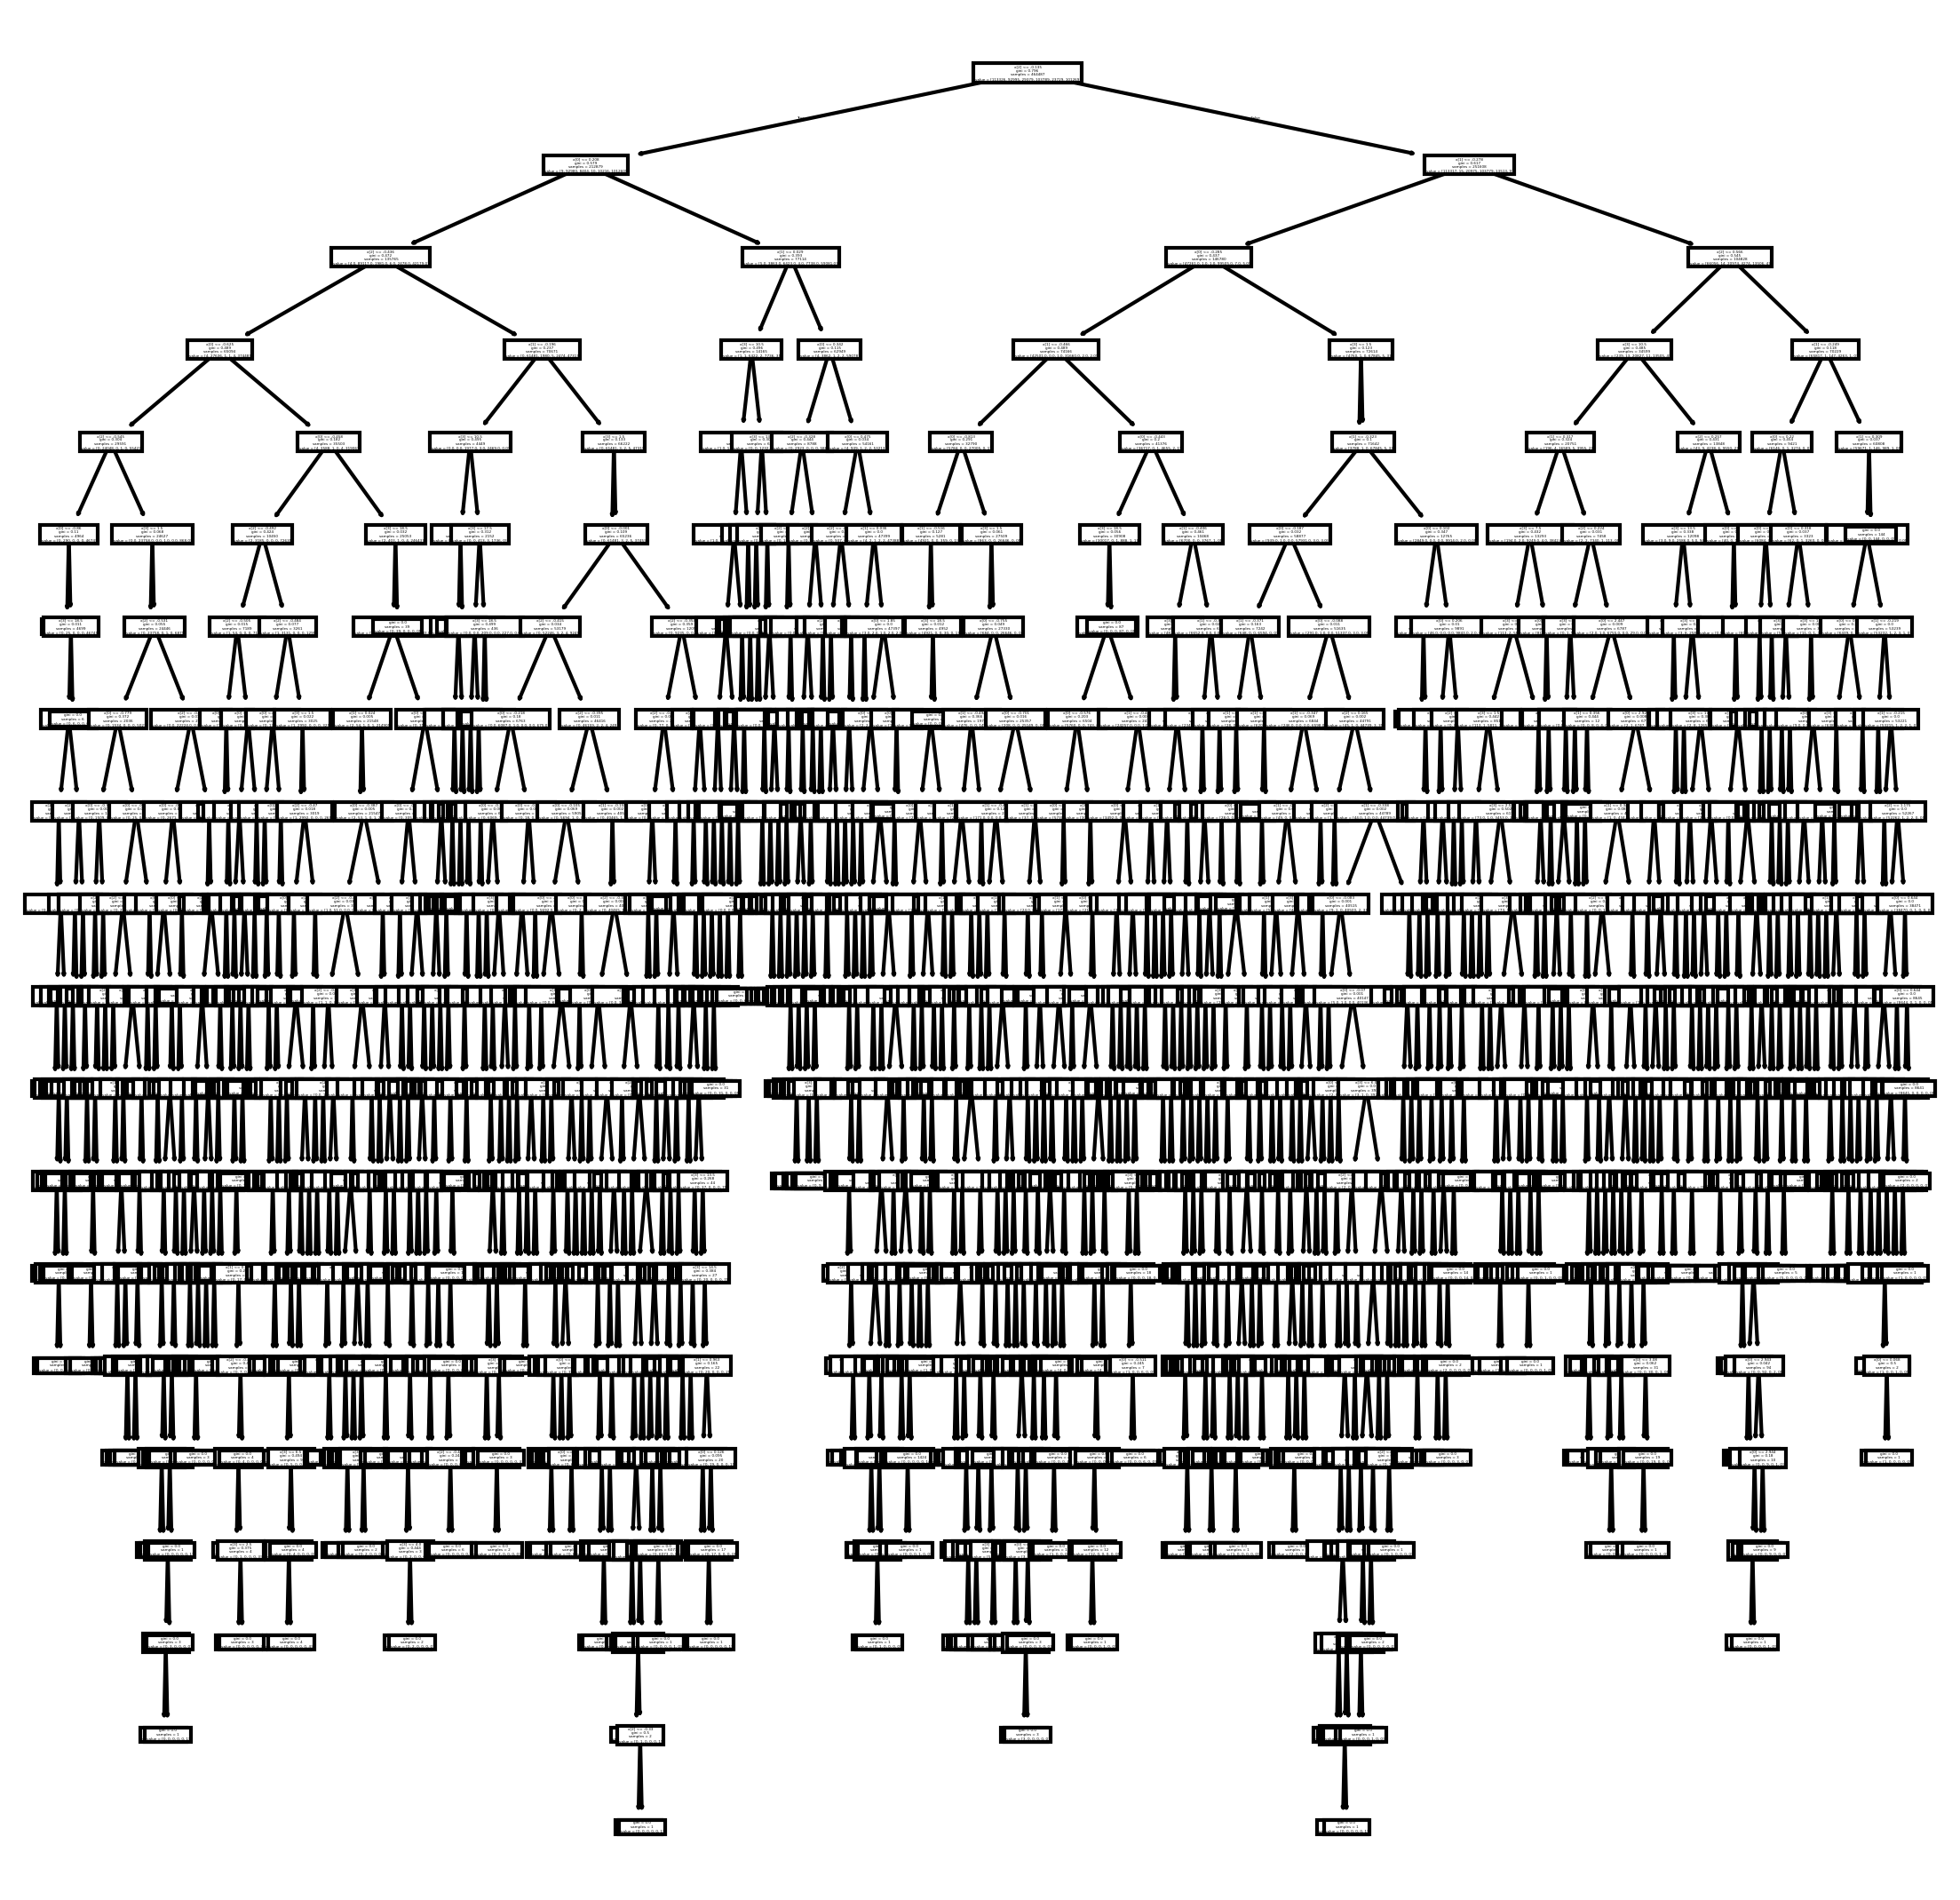

In [ ]:
#Plotting the decsion tree
from sklearn import tree
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 9), dpi=300)
tree.plot_tree(dt_d)
plt.show()

## **Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, mean_squared_error

# Predict on training, validation, and test sets
y_train_pred = dt_d.predict(X_train)
y_val_pred = dt_d.predict(X_val)
y_test_pred = dt_d.predict(X_test)

# Calculate accuracy and MSE for training, validation, and test sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Print the results
print(f"Training Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")
print(f"Training MSE: {train_mse:.4f}, Validation MSE: {val_mse:.4f}, Test MSE: {test_mse:.4f}")

# Determine if the model is overfitting or underfitting
if train_accuracy > val_accuracy and val_accuracy > test_accuracy:
    print("The model is overfitting.")
elif train_accuracy < val_accuracy:
    print("The model is underfitting.")
else:
    print("The model is well-fitted.")


Training Accuracy: 1.0000, Validation Accuracy: 0.9982, Test Accuracy: 0.9982
Training MSE: 0.0000, Validation MSE: 0.0187, Test MSE: 0.0187
The model is overfitting.


#**Random Forest Model**

In [15]:
# Importing code bloxks from the scikit learn library
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
# Checking for feature balance in the train data
clean_train['cluster_catgeory'].value_counts()

,count
cluster_catgeory,
1,188980
4,172439
6,169215
2,155064
3,48907
5,39540


Since customer Id has no prediction value and is only a unique identifier it is not included in the features in the x dataframe since including it migh lead to over fitting the model.

In [17]:
# Difine X and Y variables
X = clean_train[['luxury_sales','fresh_sales','dry_sales','outlet_city_encoded']]
y = clean_train['cluster_catgeory']

In [18]:
# Split data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [19]:
# Verify dimensions
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (464487, 4)
y_train shape: (464487,)


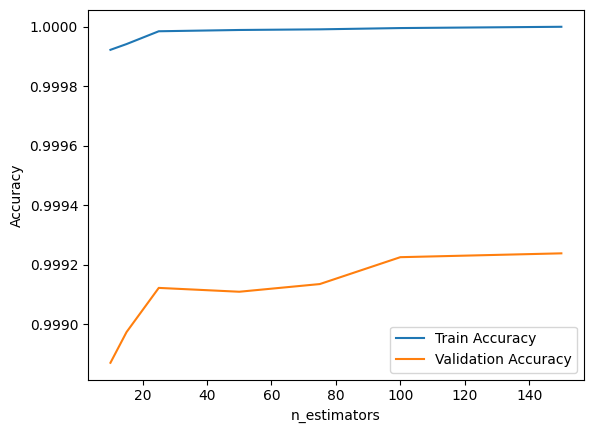

In [20]:
estimators_range = [10, 15, 25, 25, 50, 75, 100, 150]
train_scores, val_scores = [], []

for n in estimators_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    val_scores.append(accuracy_score(y_val, model.predict(X_val)))

plt.plot(estimators_range, train_scores, label="Train Accuracy")
plt.plot(estimators_range, val_scores, label="Validation Accuracy")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [21]:
# Grid Search
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [10, 15, 20, 25, 50, 75, 100]}
rf = RandomForestClassifier()
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_n_estimators = grid_search.best_params_['n_estimators']
print(f"Best n_estimators: {best_n_estimators}")

Best n_estimators: 100


In [22]:
# creating the randome forest classifier (rfc) model
rfc_model = RandomForestClassifier(n_estimators=75, random_state=42)

n_estimators is the hyperparameter in random forest which tells the number of decision trees in the forest. Higher n_estimators mean higher accuracy but also higher computational cost and time. Therefore, 25 has been settled on as the balance between accuracy, computational cost as futher increase in this hyper parameter would only provide dimnishing returns.

In [23]:
# Train the model
rfc_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=75, random_state=42)

In [24]:
# Predict using the x_test data
y_pred = rfc_model.predict(X_test)

In [25]:
# Evaluate the model
MSE = mean_squared_error(y_test, y_pred)
r2_= r2_score(y_test, y_pred)
Acs = accuracy_score(y_test, y_pred)

print(f"MSE:{MSE}")
print(f"R2:{r2_}")
print(f"Accuracy:{Acs}")

MSE:0.007111070923405822
R2:0.9979643066269954
Accuracy:0.9992959975198444


In [26]:
# confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[37862,     2,     0,    11,     0,     1],
       [    2, 30899,     0,     2,     2,    17],
       [    0,     0,  9745,     0,     2,     1],
       [   19,     1,     1, 34347,     2,     0],
       [    0,     0,    11,     1,  7949,     1],
       [    0,    24,     4,     3,     2, 33918]])

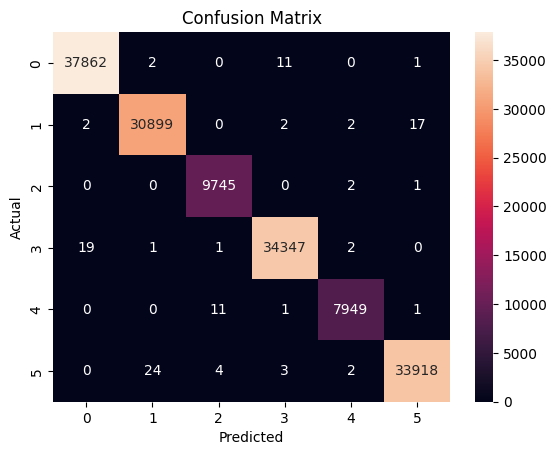

In [27]:
# heatmap of contribution matrix
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

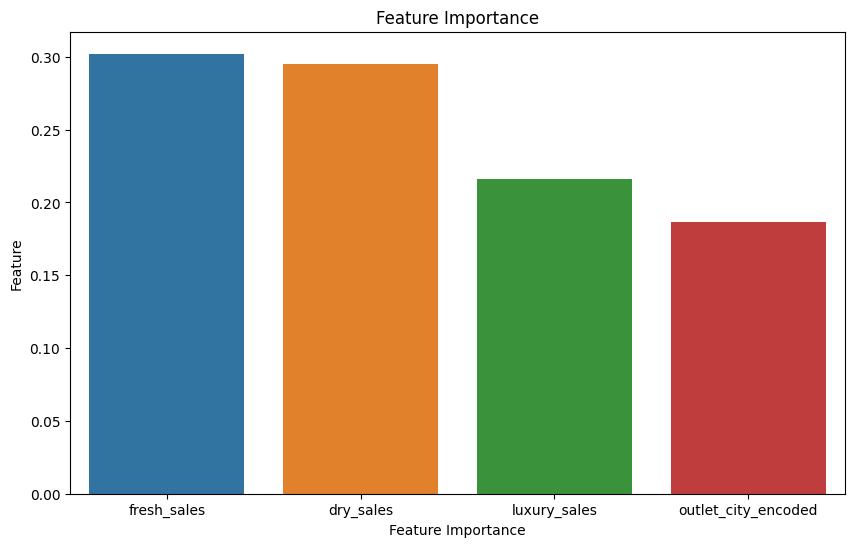

In [28]:
# importance of each feature
feature_importance = rfc_model.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# plot
plt.figure(figsize=(10, 6))
sns.barplot(y='Importance', x='Feature', data=importance_df, hue='Feature')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

In [29]:
# classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     37876
           2       1.00      1.00      1.00     30922
           3       1.00      1.00      1.00      9748
           4       1.00      1.00      1.00     34370
           5       1.00      1.00      1.00      7962
           6       1.00      1.00      1.00     33951

    accuracy                           1.00    154829
   macro avg       1.00      1.00      1.00    154829
weighted avg       1.00      1.00      1.00    154829



In [ ]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(
    rfc_model, X, y, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.title("Learning Curve")
plt.xlabel("Training Examples")
plt.ylabel("Score")
plt.grid()

plt.fill_between(
    train_sizes, train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std, alpha=0.1, color="r"
)
plt.fill_between(
    train_sizes, test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std, alpha=0.1, color="g"
)
plt

## **Evaluation**

In [30]:
# Predict on training, validation, and test sets
y_train_pred = rfc_model.predict(X_train)
y_val_pred = rfc_model.predict(X_val)
y_test_pred = rfc_model.predict(X_test)

# Calculate accuracy and MSE for training, validation, and test sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Print the results
print(f"Training Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")
print(f"Training MSE: {train_mse:.4f}, Validation MSE: {val_mse:.4f}, Test MSE: {test_mse:.4f}")

# Determine if the model is overfitting or underfitting
if train_accuracy > val_accuracy and val_accuracy > test_accuracy:
    print("The model is overfitting.")
elif train_accuracy < val_accuracy:
    print("The model is underfitting.")
else:
    print("The model is well-fitted.")

Training Accuracy: 1.0000, Validation Accuracy: 0.9991, Test Accuracy: 0.9993
Training MSE: 0.0001, Validation MSE: 0.0085, Test MSE: 0.0071
The model is well-fitted.


# **Gradient Boosting Model**

In [ ]:
# Checking for feature balance in the train data
clean_train['cluster_catgeory'].value_counts()

,count
cluster_catgeory,
1,188980
4,172439
6,169215
2,155064
3,48907
5,39540


In [ ]:
# Importing code bloxks from the scikit learn library
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
# Difine X and Y variables
X = clean_train[['luxury_sales','fresh_sales','dry_sales','outlet_city_encoded']]
y = clean_train['cluster_catgeory']

In [ ]:
# Split data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
# create the Gradient Boosting Classificatio (gbc) model
gbc_model = GradientBoostingClassifier(n_estimators=25, random_state=42)

In [ ]:
# Train the model
gbc_model.fit(X_train,y_train)

GradientBoostingClassifier(n_estimators=25, random_state=42)

In [ ]:
# predict using the model
y_pred = gbc_model.predict(X_test)

In [ ]:
# Evaluate the model
MSE = mean_squared_error(y_test, y_pred)
r2_= r2_score(y_test, y_pred)
Acs = accuracy_score(y_test, y_pred)

print(f"MSE:{MSE}")
print(f"R2:{r2_}")
print(f"Accuracy:{Acs}")

MSE:0.1473367392413566
R2:0.957821764554967
Accuracy:0.9745848645925504


[[37578     2     0   295     0     1]
 [    5 30793     0     1     4   119]
 [    2    10  8291     1  1443     1]
 [  206     0     2 34161     1     0]
 [    3     0  1568     1  6389     1]
 [    0   260     3     3     3 33682]]


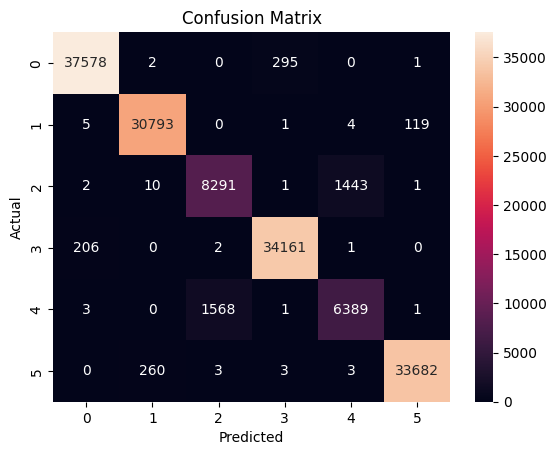

In [ ]:
# confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

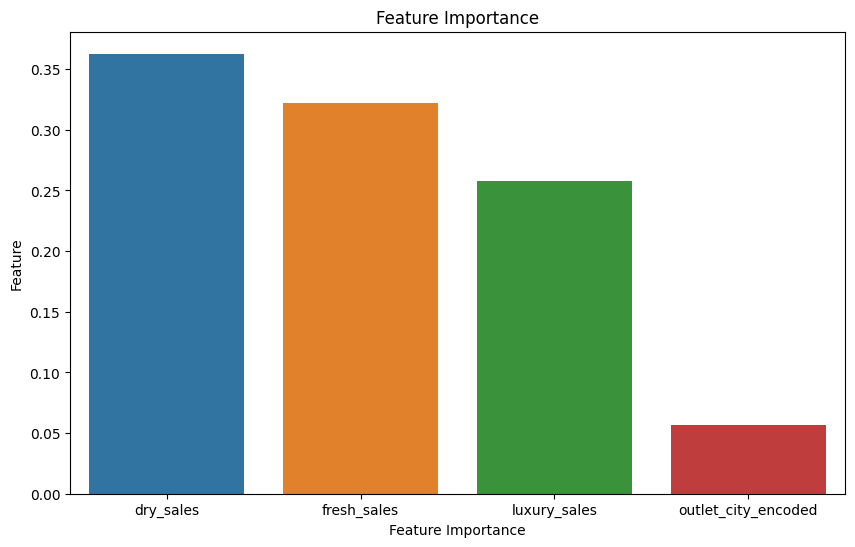

In [ ]:
# importance of each feature
feature_importance = gbc_model.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# plot
plt.figure(figsize=(10, 6))
sns.barplot(y='Importance', x='Feature', data=importance_df, hue='Feature')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

In [ ]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.99      0.99      0.99     37876
           2       0.99      1.00      0.99     30922
           3       0.84      0.85      0.85      9748
           4       0.99      0.99      0.99     34370
           5       0.81      0.80      0.81      7962
           6       1.00      0.99      0.99     33951

    accuracy                           0.97    154829
   macro avg       0.94      0.94      0.94    154829
weighted avg       0.97      0.97      0.97    154829



## **Evaluation**

In [ ]:
# Predict on training, validation, and test sets
y_train_pred = gbc_model.predict(X_train)
y_val_pred = gbc_model.predict(X_val)
y_test_pred = gbc_model.predict(X_test)

# Calculate accuracy and MSE for training, validation, and test sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Print the results
print(f"Training Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")
print(f"Training MSE: {train_mse:.4f}, Validation MSE: {val_mse:.4f}, Test MSE: {test_mse:.4f}")

# Determine if the model is overfitting or underfitting
if train_accuracy > val_accuracy and val_accuracy > test_accuracy:
    print("The model is overfitting.")
elif train_accuracy < val_accuracy:
    print("The model is underfitting.")
else:
    print("The model is well-fitted.")

Training Accuracy: 0.9748, Validation Accuracy: 0.9738, Test Accuracy: 0.9746
Training MSE: 0.1450, Validation MSE: 0.1530, Test MSE: 0.1473
The model is well-fitted.
